# 자동차 브랜드 3종 탐지 실습 — 무(無)라벨 데이터에서 NPU 시연까지
> **YOLOv9-DPI + BlackSwan NPU (Tachy-Shield) 실습 노트북 (전량 CVAT 라벨링판)**
>
> Stanford Cars에서 추출한 3개 브랜드(**audi, bmw, tesla** — 각 30장, 총 90장)를 탐지하는 모델을 만듭니다.
> 이번 데이터에는 **박스 라벨이 하나도 없습니다.** 폴더명(브랜드)만이 유일한 힌트입니다.
> 90장 전부를 **CVAT에서 직접 라벨링**하는 것이 이번 실습의 관문이자 본체입니다.

## 전체 흐름

```
[Colab]     (부록: 데이터 생성 과정) → 환경 구성 → zip 반입·CVAT 업로드본 생성
[CVAT]      라벨 3종 등록 → 90장 전량 라벨링(~45분) → YOLO 1.1 Export
[Colab/T4]  파싱·자동 QC → 분할 → 학습(1·2단계) → TACHY 컴파일 → 시연 슬라이드
[RPi4+NPU]  .tachyrt 복사 → 설정 수정(3클래스) → 실시간 추론 → 모니터 재촬영 시연
```

> 🔑 **핵심 메시지**: *"라벨이 없으면 모델도 없다 — 그리고 정답지가 없어도 라벨 품질은 잴 수 있다."*
> 이전 실습과 달리 대조할 참조 라벨이 없습니다. 대신 두 가지 현실적 QC를 씁니다:
> ① 파일명 접두어(브랜드)와 라벨 클래스의 **자동 대조** ② 팀원 간 **교차 라벨링 일관성**(같은 이미지를 두 사람이
> 라벨링해 IoU로 비교). 실무에서 정답 없는 라벨 품질을 관리하는 방식 그대로입니다.

> ⚠️ **기대치 관리 (정직 고지)**: 클래스당 학습 이미지 **24장**으로 브랜드 구분(세밀 분류에 가까운 과제)을
> 스크래치 학습하는 것은 데이터 규모상 무리입니다. 📊 mAP는 낮게 나올 수 있으며, **그것이 정상**입니다.
> 이 실습의 목표는 성능 수치가 아니라 **무라벨 데이터 → 라벨링 → 학습 → NPU 배포** 전체 사이클의 완주이고,
> "데이터 규모가 성능을 어떻게 제약하는가"를 리포트 실험으로 확인하는 것입니다.

## 예상 소요 시간 (T4 기준)

| 단계 | 소요 시간 |
| --- | --- |
| 환경 구성 (conda + 패키지) | 약 10~15분 |
| 데이터 반입 + CVAT 업로드본 생성 | 약 5분 |
| **CVAT 라벨링 (90장 전량)** | **약 45~60분** |
| 파싱·QC·분할 | 약 5분 |
| 1단계 학습 (bsnet-t, 60 epochs) | 약 5~10분 (90장이라 빠름) |
| 2단계 학습 (bsnet-t-o, 60 epochs) | 약 5~10분 |
| TACHY 컴파일 | 약 5~10분 |
| **합계** | **약 1시간 30분~2시간** |

⏱️ **운영 순서 (중요)**: 라벨이 없으면 학습을 미리 돌려둘 수 없습니다. 권장 순서 —
**3장에서 CVAT 업로드본을 먼저 만들어 라벨링을 시작**시켜 두고, 라벨링이 진행되는 동안
2장(환경 구성)과 6장(optional 파일 업로드)을 마쳐두세요. 라벨링이 끝나는 시점에 바로 학습으로 진입합니다.

⚠️ **시작 전 체크리스트**
- 런타임 유형이 **GPU (T4)** 인지 확인: `런타임 → 런타임 유형 변경 → T4 GPU`
- `stanford_cars_3classes.zip` 파일이 **내 PC에** 있는지 확인 (없으면 부록 0장으로 생성)
- `fc.out`, `block_4bit.out` 파일 준비 (6장에서 업로드)
- **CVAT 계정**: https://app.cvat.ai 무료 가입 (이메일 인증 필요 — 수업 전날 권장)

⚠️ **이 노트북은 Google Drive를 사용하지 않습니다.** 세션 초기화 시 결과가 사라지므로 8-2장의 백업 셀을 꼭 실행하세요.


---
## 0. (부록) 이 데이터셋이 만들어진 과정 — 이미 `stanford_cars_3classes.zip`이 있다면 건너뛰세요

아래 셀들은 Stanford Cars 데이터셋에서 3개 브랜드 × 30장을 추출해 zip으로 만드는 과정의 기록입니다.
**데이터 출처를 문서화**하는 것도 데이터 작업의 일부입니다 — 나중에 "이 90장이 어디서 왔는가"를 답할 수 있어야 합니다.
zip을 이미 받았다면 **1장(환경 구성)으로 바로 이동**하세요.

In [1]:
!pip -q install datasets

from datasets import load_dataset

ds = load_dataset("tanganke/stanford_cars")

print(ds)

README.md:   0%|          | 0.00/11.0k [00:00<?, ?B/s]

data/train-00000-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  504MB            

data/train-00000-of-00002.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00002.parquet: reconstructing file:   0%|          |  0.00B /  485MB            

data/train-00001-of-00002.parquet: downloading bytes:           |  0.00B            

...

Generating jpeg_compression split:   0%|          | 0/8041 [00:00<?, ? examples/s]

Generating motion_blur split:   0%|          | 0/8041 [00:00<?, ? examples/s]

Generating pixelate split:   0%|          | 0/8041 [00:00<?, ? examples/s]

Generating spatter split:   0%|          | 0/8041 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 8144
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 8041
    })
    contrast: Dataset({
        features: ['image', 'label'],
        num_rows: 8041
    })
    gaussian_noise: Dataset({
        features: ['image', 'label'],
        num_rows: 8041
    })
    impulse_noise: Dataset({
        features: ['image', 'label'],
        num_rows: 8041
    })
    jpeg_compression: Dataset({
        features: ['image', 'label'],
        num_rows: 8041
    })
    motion_blur: Dataset({
        features: ['image', 'label'],
        num_rows: 8041
    })
    pixelate: Dataset({
        features: ['image', 'label'],
        num_rows: 8041
    })
    spatter: Dataset({
        features: ['image', 'label'],
        num_rows: 8041
    })
})


In [3]:
# 3. 전체 클래스 이름 확인

train_ds = ds["train"]

print(train_ds)
print("전체 학습 이미지 수:", len(train_ds))
class_names = train_ds.features["label"].names

print("전체 클래스 수:", len(class_names))

for i, name in enumerate(class_names):
    print(i, name)

Dataset({
    features: ['image', 'label'],
    num_rows: 8144
})
전체 학습 이미지 수: 8144
전체 클래스 수: 196
0 AM General Hummer SUV 2000
1 Acura RL Sedan 2012
2 Acura TL Sedan 2012
3 Acura TL Type-S 2008
4 Acura TSX Sedan 2012
5 Acura Integra Type R 2001
6 Acura ZDX Hatchback 2012
7 Aston Martin V8 Vantage Convertible 2012
8 Aston Martin V8 Vantage Coupe 2012
9 Aston Martin Virage Convertible 2012
10 Aston Martin Virage Coupe 2012
11 Audi RS 4 Convertible 2008
12 Audi A5 Coupe 2012
13 Audi TTS Coupe 2012
14 Audi R8 Coupe 2012
15 Audi V8 Sedan 1994
16 Audi 100 Sedan 1994
17 Audi 100 Wagon 1994
18 Audi TT Hatchback 2011
19 Audi S6 Sedan 2011
20 Audi S5 Convertible 2012
21 Audi S5 Coupe 2012
22 Audi S4 Sedan 2012
23 Audi S4 Sedan 2007
24 Audi TT RS Coupe 2012
25 BMW ActiveHybrid 5 Sedan 2012
26 BMW 1 Series Convertible 2012
27 BMW 1 Series Coupe 2012
28 BMW 3 Series Sedan 2012
29 BMW 3 Series Wagon 2012
30 BMW 6 Series Convertible 2007
31 BMW X5 SUV 2007
32 BMW X6 SUV 2012
33 BMW M3 Coupe 2012
34 B

In [6]:
# 4. 저장할 자동차 3종 선택
selected_classes = [
    "Audi TTS Coupe 2012",
    "BMW M3 Coupe 2012",
    "Tesla Model S Sedan 2012"
]

for name in selected_classes:
    print(name, "→ class id:", class_names.index(name))

Audi TTS Coupe 2012 → class id: 13
BMW M3 Coupe 2012 → class id: 33
Tesla Model S Sedan 2012 → class id: 184


In [7]:
# 5. 자동차 종류별 폴더 생성 후 30장씩 저장

import os
import re

OUTPUT_DIR = "/content/stanford_cars_3classes"
NUM_IMAGES = 30

os.makedirs(OUTPUT_DIR, exist_ok=True)


# Windows/Linux에서 폴더명으로 쓰기 어려운 문자 제거
def safe_folder_name(name):
    return re.sub(r'[\\/:*?"<>|]', "_", name)


for class_name in selected_classes:

    class_id = class_names.index(class_name)

    folder_name = safe_folder_name(class_name)
    save_dir = os.path.join(OUTPUT_DIR, folder_name)

    os.makedirs(save_dir, exist_ok=True)

    count = 0

    for sample in train_ds:

        if sample["label"] == class_id:

            image = sample["image"].convert("RGB")

            save_path = os.path.join(
                save_dir,
                f"{count+1:03d}.jpg"
            )

            image.save(save_path)

            count += 1

            if count >= NUM_IMAGES:
                break

    print(f"✅ {class_name}: {count}장 저장")

✅ Audi TTS Coupe 2012: 30장 저장
✅ BMW M3 Coupe 2012: 30장 저장
✅ Tesla Model S Sedan 2012: 30장 저장


In [8]:
# 6. 폴더별 이미지 개수 확인

for folder in os.listdir(OUTPUT_DIR):

    folder_path = os.path.join(OUTPUT_DIR, folder)

    if os.path.isdir(folder_path):

        files = os.listdir(folder_path)

        print(
            folder,
            "→",
            len(files),
            "장"
        )

BMW M3 Coupe 2012 → 30 장
Tesla Model S Sedan 2012 → 30 장
Audi TTS Coupe 2012 → 30 장


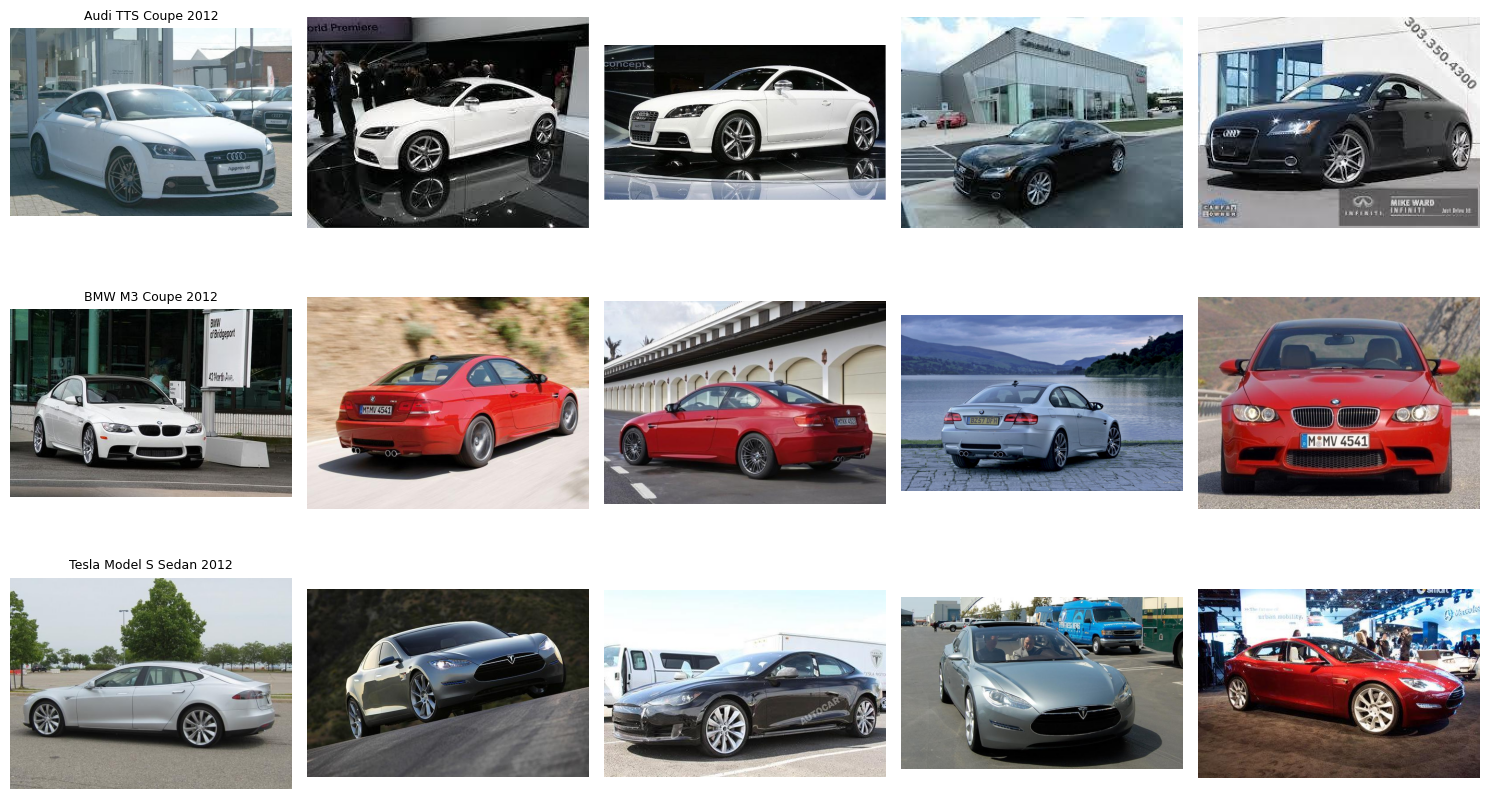

In [9]:
# 7. 저장된 자동차 이미지 확인

import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(
    len(selected_classes),
    5,
    figsize=(15, 9)
)

for row, class_name in enumerate(selected_classes):

    folder = os.path.join(
        OUTPUT_DIR,
        safe_folder_name(class_name)
    )

    image_files = sorted(os.listdir(folder))[:5]

    for col, file_name in enumerate(image_files):

        image_path = os.path.join(folder, file_name)

        img = Image.open(image_path)

        axes[row, col].imshow(img)
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_title(
                class_name,
                fontsize=9
            )

plt.tight_layout()
plt.show()

In [10]:
# 8. 전체 데이터셋 ZIP 압축

import shutil

shutil.make_archive(
    "/content/stanford_cars_3classes",
    "zip",
    OUTPUT_DIR
)

print("압축 완료!")

압축 완료!


In [11]:
# 9. ZIP 다운로드

from google.colab import files

files.download(
    "/content/stanford_cars_3classes.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 1. Colab 런타임 준비 (Miniforge 직접 설치)

yolov9-dpi는 특정 라이브러리 버전(Python 3.8, torch 1.13.1)만 지원하므로 conda 환경을 사용합니다.

💡 condacolab은 Colab 기본 Python 버전에 고정되어 있어, Colab이 Python 버전을 올리면
`Colab's Python (3.13) does not match expected version` 오류로 깨집니다.
여기서는 **Miniforge를 `/opt/conda`에 직접 설치**하는 방식을 사용합니다.
- Colab Python 버전과 무관하게 동작 (향후 버전 업에도 안전)
- **런타임 재시작 불필요** — 설치 후 바로 다음 셀 진행

설치에 약 1~2분 소요됩니다.

In [ ]:
import os

if not os.path.exists('/opt/conda/bin/conda'):
    !wget -q https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh -O /tmp/miniforge.sh
    !bash /tmp/miniforge.sh -b -p /opt/conda
    !rm /tmp/miniforge.sh
    print('Miniforge 설치 완료')
else:
    print('Miniforge 이미 설치됨')

# 이후 모든 ! 셸 명령에서 conda/mamba를 찾을 수 있도록 PATH 등록
os.environ['PATH'] = '/opt/conda/bin:' + os.environ['PATH']

설치 확인 — conda와 mamba 버전이 출력되면 정상입니다.

In [ ]:
!conda --version && mamba --version

---
## 2. 저장소 준비 (로컬 디스크)

모든 작업은 Colab 로컬 디스크 `/content` 아래에서 진행합니다. Drive 마운트 과정이 없어 시작이 빠르고 권한 팝업도 없습니다.

⚠️ 대신 세션 초기화 시 결과물이 사라지므로, **8-2장의 백업 다운로드**를 잊지 마세요.

In [ ]:
%cd /content

YOLOv9-DPI 저장소를 복제합니다. (이미 복제되어 있다면 `already exists` 메시지가 나와도 무방합니다.)

In [ ]:
!git clone https://github.com/Deeper-I/yolov9-dpi.git
%cd /content/yolov9-dpi

`py38` 이름의 Python 3.8 conda 환경을 생성합니다.

In [ ]:
!mamba create -n py38 python=3.8 -y

### 2-1. 라이브러리 경로 설정 (ABI 충돌 방지)

conda-forge 최신 빌드의 ICU 라이브러리는 시스템 `libstdc++`보다 새로운 C++ ABI(`CXXABI_1.3.15`)를 요구합니다.
torch가 시스템 libstdc++를 먼저 로드해버리면 이후 `import sqlite3`에서
`` version `CXXABI_1.3.15' not found `` 오류가 발생합니다.

conda 환경 내부의 최신 libstdc++가 우선 로드되도록 `LD_LIBRARY_PATH`를 설정해 해결합니다.
(새 libstdc++는 하위 호환이므로 torch/CUDA에도 안전합니다.)

In [ ]:
import os
os.environ['LD_LIBRARY_PATH'] = '/opt/conda/envs/py38/lib:' + os.environ.get('LD_LIBRARY_PATH', '')
print('LD_LIBRARY_PATH =', os.environ['LD_LIBRARY_PATH'])

In [ ]:
%%writefile requirements.txt
torch==1.13.1
torchvision==0.14.1
PyYAML==6.0.1
opencv-python
pandas==1.1.5
DDesignerAPI
IPython
psutil
matplotlib>=3.2.2
seaborn
tensorboard
Pillow==9.4.0
commentjson
ordered_set
onnx==1.14.1
networkx==2.6.3
easydict
tqdm
# compile_linux.py는 0.1.0의 모듈 구조(platform_converter/utils/yolov9)를 기준으로 작성됨
# 0.1.1부터 모듈 재편으로 ModuleNotFoundError 발생 → 반드시 버전 고정
TACHY-Compiler==0.1.0

In [ ]:
!conda run -n py38 pip install -r requirements.txt

### 2-2. 환경 검증

학습 시작 전에 핵심 모듈이 정상 import되는지, GPU가 잡히는지 한 번에 확인합니다.
`OK | torch 1.13.1 ... CUDA: True` 가 나와야 합니다.
(`can not import tensorflow` 경고가 보여도 무시하세요 — 선택적 의존성입니다.)

In [ ]:
!conda run -n py38 python3 -c "import torch, sqlite3, cv2, onnx, tachy_compiler.platform_converter.utils.yolov9.deploy_pt_yolov9; print('OK | torch', torch.__version__, '| CUDA:', torch.cuda.is_available())"

---
## 3. 데이터 반입 및 CVAT 업로드본 생성

`stanford_cars_3classes.zip`을 업로드해 풀고, 구조를 확인합니다.

| 항목 | 내용 |
| --- | --- |
| 클래스 | 3개 — `audi`(0), `bmw`(1), `tesla`(2) *(알파벳순 = 표준 순서)* |
| 규모 | 브랜드별 30장, 총 90장 |
| 라벨 | **없음** — 폴더명(브랜드)만이 힌트. 박스는 전부 우리가 그립니다 |

CVAT 업로드용 zip을 만들 때 파일명에 **브랜드 접두어**(`audi_001.jpg` 형태)를 붙입니다. 목적 두 가지:
① 라벨링 중 화면 하단 파일명으로 브랜드를 즉시 확인 → 클래스 선택 실수·판단 시간 감소
② 라벨링 후 "파일명 브랜드 vs 라벨 클래스" **자동 대조 QC**의 근거 (3-3에서 사용)

In [ ]:
from google.colab import files
import zipfile, os, glob
from pathlib import Path

up = files.upload()                                   # stanford_cars_3classes.zip 선택
src_zip = '/content/' + list(up.keys())[0]
RAW = Path('/content/cars_raw')
with zipfile.ZipFile(src_zip) as z:
    z.extractall(RAW)

CANONICAL = ['audi', 'bmw', 'tesla']                  # 표준 클래스 순서 (알파벳)
root = next(RAW.glob('**/Audi')).parent               # 브랜드 폴더들의 부모 탐색
counts = {}
for d in sorted(root.iterdir()):
    if d.is_dir():
        counts[d.name] = len(list(d.glob('*.jpg')))
print('브랜드별 이미지:', counts)
assert set(k.lower() for k in counts) == set(CANONICAL), '브랜드 폴더 구성이 예상과 다릅니다'
assert not list(root.glob('**/*.txt')), '라벨 파일이 발견됨 — 이 노트북은 무라벨 시나리오용입니다'
print('✅ 총', sum(counts.values()), '장 / 라벨 없음 확인 (전량 CVAT 라벨링 대상)')

In [ ]:
# CVAT 업로드본 생성: 브랜드 접두어 부여 (✅ 실데이터 검증 완료 — 90장)
with zipfile.ZipFile('/content/cvat_upload_cars.zip', 'w') as z:
    for d in sorted(root.iterdir()):
        if not d.is_dir():
            continue
        brand = d.name.lower()
        for p in sorted(d.glob('*.jpg')):
            z.write(p, arcname=f'{brand}_{p.name}')
n_up = len(zipfile.ZipFile('/content/cvat_upload_cars.zip').namelist())
print(f'✅ cvat_upload_cars.zip 생성: {n_up}장')
files.download('/content/cvat_upload_cars.zip')       # 내 PC로 다운로드 → CVAT에 업로드

### 3-1. CVAT에서 90장 전량 라벨링하기 (Colab 밖 — 브라우저)

**app.cvat.ai** (호스팅, 무료) 기준입니다.

**① 프로젝트·라벨 생성**
1. 로그인 → `Projects` → `+` → 이름 `cars3`
2. **Add label**로 3개 등록 — 철자 정확히 (등록 순서는 무관: 파서가 이름 기준 재매핑 ✅):
   `audi` `bmw` `tesla`

**② 태스크 생성**
3. `+ Create new task` → 이름 `batch01` → `cvat_upload_cars.zip` 업로드 → Submit

**③ 라벨링 규칙 (90장, 목표 45분 — 장당 30초 페이스)**
- 화면 하단 **파일명의 접두어가 곧 브랜드**입니다 (`tesla_012.jpg` → tesla)
- **주 피사체 차량 1대만** 라벨링합니다 — Stanford Cars는 차 한 대가 화면 대부분을 차지하는 구도입니다
- 배경에 작게 보이는 다른 차량은 **라벨링하지 않습니다** (팀 전체가 같은 규칙 공유 — 일관성이 정확성보다 중요)
- 박스는 차체에 **타이트하게** (사이드미러 포함, 그림자 제외)
- 단축키: `N` 새 박스 · `Ctrl+S` 수시 저장 · `F` 다음 프레임

**④ (선택·권장) 교차 라벨링** — 팀 실습인 경우: 팀원 2명이 **같은 10장**(예: 각 브랜드 앞 3~4장)을 서로
몰래 중복 라벨링해 두세요. 3-3에서 두 사람의 라벨을 IoU로 대조해 **라벨 일관성**을 측정합니다.
"정답지 없이 라벨 품질을 재는" 실무 기법(inter-annotator agreement)입니다.

**⑤ Export**
4. 저장 후 태스크 메뉴 → `Export task dataset` → 포맷 **`YOLO 1.1`** → zip 다운로드

⏱️ **이 시간 동안 Colab에서는**: 2장(환경 구성)과 6장(optional 파일 업로드)을 진행해 두세요.

### 3-2. CVAT Export 업로드 및 파싱 (✅ 검증 완료)

CVAT `YOLO 1.1` export의 클래스 번호는 **여러분이 라벨을 등록한 순서** 기준입니다.
파서가 `obj.names`를 읽어 표준 순서(`audi=0, bmw=1, tesla=2`)로 재매핑합니다.
*(사전 검증: 등록 순서를 tesla→audi→bmw로 뒤섞은 모의 export에서 정확 재매핑 확인)*

In [ ]:
up = files.upload()                                   # CVAT YOLO 1.1 export zip 선택
cvat_zip = '/content/' + list(up.keys())[0]

# ===== 검증 완료 파서 =====
def parse_cvat_yolo11(zip_path, out_dir, canonical=CANONICAL):
    warns = []
    os.makedirs(out_dir, exist_ok=True)
    with zipfile.ZipFile(zip_path) as z:
        nm = next((n for n in z.namelist() if n.endswith('obj.names')), None)
        assert nm, 'obj.names 없음 — Export 포맷이 YOLO 1.1인지 확인'
        cvat_names = [l.strip().lower() for l in
                      z.read(nm).decode('utf-8').splitlines() if l.strip()]
        remap = {}
        for i, nme in enumerate(cvat_names):
            if nme in canonical:
                remap[i] = canonical.index(nme)
            else:
                warns.append(f"CVAT 라벨 '{nme}'은 표준 클래스에 없음 — 해당 박스 제외")
        cnt = 0
        for m in z.namelist():
            if not m.endswith('.txt') or m.endswith('train.txt'):
                continue
            out = []
            for line in z.read(m).decode('utf-8').splitlines():
                p = line.split()
                if len(p) >= 5 and int(p[0]) in remap:
                    out.append(' '.join([str(remap[int(p[0])])] + p[1:5]))
            with open(os.path.join(out_dir, os.path.basename(m)), 'w') as f:
                f.write('\n'.join(out))
            cnt += 1
    return cnt, remap, warns

STU = '/content/student_labels'
n, remap, warns = parse_cvat_yolo11(cvat_zip, STU)
print(f'✅ 파싱: 라벨 파일 {n}개 | 재매핑 {remap}')
for w in warns:
    print('⚠️', w)
assert n >= 80, f'라벨 파일이 {n}개뿐입니다 — 전량(90장) 라벨링 후 Export 했는지 확인'

### 3-3. ★정답지 없는 라벨 QC★ (✅ 검증 완료)

참조 라벨이 없어도 품질은 잴 수 있습니다 — 두 층위로 검사합니다.

**자동 QC (전원 필수)** — 파일명 접두어를 약한 참조 라벨로 활용:
| 검사 | 잡아내는 실수 |
|---|---|
| 박스 0개 이미지 | 라벨링 누락 (저장 안 하고 넘어감) |
| 접두어 ≠ 라벨 클래스 | 클래스 선택 실수 (audi 이미지에 bmw 라벨 등) |
| 극단 크기 박스 | 오조작 (전체 화면 드래그, 점 클릭) |

**교차 일관성 (팀 실습 선택)** — 중복 라벨링한 10장을 두 사람 간 IoU로 대조.
평균 IoU가 곧 팀의 **라벨링 합의도**입니다. 📊 잘 합의된 팀: 0.85+ / 규칙이 안 맞은 팀: 0.7 이하 —
점수가 낮다면 "타이트 기준"이나 "그림자 포함 여부"가 서로 달랐을 가능성이 큽니다.

In [ ]:
# ===== 자동 QC (검증 완료: 클래스 불일치 케이스 정확 검출) =====
issues = []
for lp in sorted(glob.glob(f'{STU}/*.txt')):
    stem = os.path.basename(lp)[:-4]
    brand = stem.split('_')[0]
    if brand not in CANONICAL:
        continue
    exp = CANONICAL.index(brand)
    lines = [l for l in open(lp).read().splitlines() if l.strip()]
    if not lines:
        issues.append((stem, '박스 없음')); continue
    for l in lines:
        c, cx, cy, w, h = map(float, l.split()[:5])
        if int(c) != exp:
            issues.append((stem, f'클래스 불일치 (기대 {CANONICAL[exp]}, 라벨 {CANONICAL[int(c)]})'))
        if w * h > 0.98 or w * h < 0.01:
            issues.append((stem, f'극단 크기 박스 (면적비 {w*h:.3f})'))

print(f'QC 이슈: {len(issues)}건')
for s, msg in issues[:15]:
    print(f'  {s}: {msg}')
if issues:
    print('\n⚠️ 위 이미지들은 CVAT에서 수정 후 다시 Export → 3-2부터 재실행하세요')
else:
    print('✅ 자동 QC 통과')

In [ ]:
# (선택) 교차 라벨링 일관성 — 팀원의 export zip을 추가 업로드해 중복 이미지끼리 IoU 대조
# 사용법: RUN_CROSS = True로 바꾸고 실행 → 팀원 zip 선택
RUN_CROSS = False

if RUN_CROSS:
    import numpy as np
    up2 = files.upload()
    peer_zip = '/content/' + list(up2.keys())[0]
    PEER = '/content/peer_labels'
    parse_cvat_yolo11(peer_zip, PEER)

    def read_yolo(path):
        rows = []
        if os.path.exists(path):
            for line in open(path).read().splitlines():
                p = line.split()
                if len(p) >= 5:
                    rows.append(tuple(map(float, p[:5])))
        return rows

    def iou(a, b):
        x1, y1 = max(a[0], b[0]), max(a[1], b[1])
        x2, y2 = min(a[2], b[2]), min(a[3], b[3])
        inter = max(x2 - x1, 0) * max(y2 - y1, 0)
        ua = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
        return inter / ua if ua > 0 else 0.0

    common = sorted(set(os.listdir(STU)) & set(os.listdir(PEER)))
    ious, cls_mismatch = [], 0
    for name in common:
        A_ = read_yolo(f'{STU}/{name}'); B_ = read_yolo(f'{PEER}/{name}')
        if not A_ or not B_:
            continue
        # 주 피사체 1대 규칙이므로 가장 큰 박스끼리 비교
        big = lambda rows: max(rows, key=lambda r: r[3] * r[4])
        (ca, cxa, cya, wa, ha), (cb, cxb, cyb, wb, hb) = big(A_), big(B_)
        box = lambda cx, cy, w, h: (cx-w/2, cy-h/2, cx+w/2, cy+h/2)
        ious.append(iou(box(cxa, cya, wa, ha), box(cxb, cyb, wb, hb)))
        cls_mismatch += int(ca != cb)
    if ious:
        print(f'중복 라벨 {len(ious)}장 | 평균 IoU {np.mean(ious):.3f} | 클래스 불일치 {cls_mismatch}건')
        print('📊 0.85+ 합의 양호 / 0.7 이하면 라벨링 규칙 재합의 필요')
    else:
        print('중복 라벨링된 이미지가 없습니다 — 3-1 ④ 참고')
else:
    print('건너뜀 (팀 실습 시 RUN_CROSS=True)')

### 3-4. 분할 및 GT 시각화

브랜드별 24/6 **층화 분할**(train/val)합니다. 90장뿐이므로 test는 따로 떼지 않고 val을 겸용합니다
(yaml에서 test=val — 시연 슬라이드도 val에서 뽑습니다). 분할 후 GT를 눈으로 최종 확인하세요 —
박스가 어긋나면 3-2(재매핑)를, 클래스가 이상하면 3-3(QC)을 다시 보세요.

In [ ]:
import shutil, random
DATASET_DIR = Path('/content/datasets/cars3')
for sp in ['train', 'val']:
    (DATASET_DIR / 'images' / sp).mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / 'labels' / sp).mkdir(parents=True, exist_ok=True)

random.seed(42)
n_train = {b: 0 for b in CANONICAL}
for brand in CANONICAL:
    stems = sorted(os.path.basename(p)[:-4] for p in glob.glob(f'{STU}/{brand}_*.txt'))
    random.shuffle(stems)
    for k, stem in enumerate(stems):
        sp = 'train' if k < int(len(stems) * 0.8) else 'val'
        # 원본 이미지 위치: 접두어 제거 후 브랜드 폴더에서 탐색 (폴더명 대소문자 대응)
        orig_name = stem[len(brand) + 1:] + '.jpg'
        src_img = None
        for d in root.iterdir():
            if d.is_dir() and d.name.lower() == brand:
                src_img = d / orig_name
        shutil.copy(src_img, DATASET_DIR / 'images' / sp / f'{stem}.jpg')
        shutil.copy(f'{STU}/{stem}.txt', DATASET_DIR / 'labels' / sp / f'{stem}.txt')
        n_train[brand] += (sp == 'train')

for sp in ['train', 'val']:
    n_img = len(list((DATASET_DIR / 'images' / sp).glob('*.jpg')))
    print(f'{sp:>5}: {n_img}장')
print('브랜드별 train:', n_train, '  # ✅ 기대: 각 24장 내외')

In [ ]:
import cv2, random
import matplotlib.pyplot as plt

CLASS_NAMES = CANONICAL
COLORS = [(220, 20, 60), (30, 144, 255), (50, 205, 50)]

samples = random.sample(sorted((DATASET_DIR / 'images' / 'train').glob('*.jpg')), 6)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, img_path in zip(axes.flat, samples):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]
    lbl_path = DATASET_DIR / 'labels' / 'train' / (img_path.stem + '.txt')
    if lbl_path.exists():
        for line in lbl_path.read_text().splitlines():
            if not line.strip():
                continue
            c, cx, cy, w, h = map(float, line.split())
            c = int(c)
            x1, y1 = int((cx - w/2) * W), int((cy - h/2) * H)
            x2, y2 = int((cx + w/2) * W), int((cy + h/2) * H)
            cv2.rectangle(img, (x1, y1), (x2, y2), COLORS[c], 3)
            cv2.putText(img, CLASS_NAMES[c], (x1, max(y1 - 8, 20)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, COLORS[c], 2)
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

### 3-5. 데이터셋 설정 파일(yaml) 생성

In [ ]:
%%writefile data/cars3.yaml
train: /content/datasets/cars3/images/train
val: /content/datasets/cars3/images/val
test: /content/datasets/cars3/images/val

nc: 3
names: ['audi', 'bmw', 'tesla']

### 3-6. Ultralytics 폰트 사전 배치

학습 시작 시 `check_dataset()`이 라벨 표시용 `Arial.ttf`를 `ultralytics.com/assets`에서 내려받으려 하는데,
이 주소는 현재 **HTTP 308 리다이렉트**를 반환하고 Python 3.8의 urllib은 308을 따라가지 못해 학습이 시작조차 안 됩니다.

`check_font()`는 파일이 이미 존재하면 다운로드를 건너뛰므로, GitHub의 새 주소에서 폰트를 **미리 받아 배치**해 우회합니다.

In [ ]:
import os, urllib.request

font_dir = os.path.expanduser('~/.config/Ultralytics')
os.makedirs(font_dir, exist_ok=True)

base = 'https://github.com/ultralytics/assets/releases/download/v0.0.0'
for fname in ['Arial.ttf', 'Arial.Unicode.ttf']:
    dst = os.path.join(font_dir, fname)
    if not os.path.exists(dst):
        urllib.request.urlretrieve(f'{base}/{fname}', dst)
        print(f'배치 완료: {dst} ({os.path.getsize(dst)/1e3:.0f} KB)')
    else:
        print(f'이미 존재: {dst}')

---
## 4. 1단계 학습: 기본 모델 (bsnet-t)

`bsnet-t.yaml` 설정으로 기본 모델을 처음부터(`--weights ''`) 학습합니다.

⏱️ T4 기준 약 20~30분 소요. 진행 중 epoch별 `mAP50` 이 점점 올라가는지 확인하세요.

⚠️ **재실행 주의**: 학습을 다시 돌리면 `runs/train/bsnet-t2`, `bsnet-t3`처럼 새 폴더가 생깁니다.
이 경우 이후 컴파일 단계의 경로도 함께 바꿔야 하므로, 재학습 시에는 기존 폴더를 지우고 시작하는 것을 권장합니다.

💡 **소량 데이터 대응**: 이전 실습(1,000장+) 대비 데이터가 72장뿐이므로 `--batch 16`, `--epochs 60`으로
조정했습니다 (epoch당 5스텝 × 60 = 300스텝 — 그래도 총 스텝 수는 이전 실습보다 훨씬 적습니다).
📊 90장 스크래치 학습의 mAP50 예상: 0.3~0.7 사이 넓은 변동 — **낮아도 파이프라인 실패가 아닙니다** (0장 기대치 관리 참고).

In [ ]:
!conda run --no-capture-output -n py38 python3 train.py \
  --workers 16 \
  --device 0 \
  --batch 16 \
  --data data/cars3.yaml \
  --img 416 \
  --cfg models/deeper-i/bsnet-t.yaml \
  --weights '' \
  --name bsnet-t \
  --hyp hyp.scratch.yaml \
  --min-items 0 \
  --epochs 60 \
  --close-mosaic 3 \
  --optimizer SGD

### 4-1. 1단계 학습 결과 확인

In [ ]:
from IPython.display import Image as IPImage, display
from pathlib import Path

run_dir = Path('runs/train/bsnet-t')
for name in ['results.png', 'confusion_matrix.png', 'val_batch0_pred.jpg']:
    p = run_dir / name
    if p.exists():
        print(f'--- {name} ---')
        display(IPImage(str(p), width=900))
    else:
        print(f'{name} 없음 (학습 폴더 이름 확인: runs/train/ 아래를 확인하세요)')

---
## 5. 2단계 학습: 최적화 모델 (bsnet-t-o)

1단계의 `best.pt`를 초기 가중치로 사용해 NPU 배포용 최적화 모델을 학습합니다.
하이퍼파라미터도 `hyp.optimize.yaml`로 변경됩니다.

⏱️ T4 기준 약 20~30분 소요.

In [ ]:
!conda run --no-capture-output -n py38 python3 train.py \
  --workers 16 \
  --device 0 \
  --batch 16 \
  --data data/cars3.yaml \
  --img 416 \
  --cfg models/deeper-i/bsnet-t-o.yaml \
  --weights './runs/train/bsnet-t/weights/best.pt' \
  --name bsnet-t-o \
  --hyp hyp.optimize.yaml \
  --min-items 0 \
  --epochs 60 \
  --close-mosaic 3 \
  --optimizer SGD

In [ ]:
# 두 단계 가중치가 모두 생성되었는지 확인
!ls -lh runs/train/bsnet-t/weights/best.pt runs/train/bsnet-t-o/weights/best.pt

---
## 6. TACHY 컴파일용 optional 파일 업로드

`fc.out`, `block_4bit.out` 두 파일은 저장소에 포함되어 있지 않습니다.
yolov9-dpi README에 안내된 경로에서 **내 PC로 다운로드해 둔 뒤**, 아래 셀을 실행하면 나오는 업로드 버튼으로 **두 파일을 한 번에 선택**해 올립니다.

(파일 크기에 따라 업로드에 수 분이 걸릴 수 있습니다. 셀 좌측 진행 표시가 끝날 때까지 기다리세요.)

In [ ]:
import os, shutil
from google.colab import files

os.makedirs('compile/optional', exist_ok=True)
uploaded = files.upload()  # fc.out, block_4bit.out 두 파일 선택

for name in uploaded:
    shutil.move(name, f'compile/optional/{name}')
    print('배치 완료:', f'compile/optional/{name}')

!chmod +x ./compile/optional/fc.out ./compile/optional/block_4bit.out
!ls -lh ./compile/optional/

---
## 7. 컴파일 설정 확인

`compile/compile_linux.py` 상단의 사용자 설정 영역을 확인합니다.

| 설정 | 이번 실습 값 | 설명 |
| --- | --- | --- |
| `PRE_PARAM_DIR` | `../runs/train/bsnet-t/weights` | 기본 모델 가중치 폴더 |
| `OPT_PARAM_DIR` | `../runs/train/bsnet-t-o/weights` | 최적화 모델 가중치 폴더 |
| `ONNX_INPUT_SHAPE` | `1 3 256 416` | (B, C, H, W) |
| `TACHY_INPUT_SHAPE` | `1 256 416 3` | (B, H, W, C) |

💡 **왜 416×416이 아니라 256×416인가?**

학습은 `--img 416`(정사각 기준)으로 했지만, 모델은 fully convolutional이라 다른 입력 크기로도 추론이 가능합니다.
라즈베리파이의 카메라 예제(`app.py`)와 후처리 설정(`post_process_256x416.json`)이
**256×416 (가로형)** 기준으로 구성되어 있으므로, 카메라 시연을 위해 저장소 기본값인 256×416을 그대로 사용합니다.
이름(`--name`)도 매뉴얼 기본값(`bsnet-t`, `bsnet-t-o`)을 그대로 썼기 때문에 **수정 없이 기본 설정으로 컴파일 가능합니다.**

아래 셀로 현재 설정값을 출력해 위 표와 일치하는지 확인만 하세요.

⚠️ **학습 폴더 이름이 밀린 경우** (`runs/train/` 아래가 `bsnet-t2`, `bsnet-t-o2` 등):
이전 학습이 중간에 실패하면 빈 폴더가 남아 재학습 결과가 `-2` 접미사 폴더로 들어갑니다.
이때는 아래 두 가지를 확인·수정해야 합니다.

1. **2단계 학습의 `--weights` 경로**가 실제 가중치가 있는 폴더(`bsnet-t2` 등)를 가리켰는지
2. `compile/compile_linux.py`의 `PRE_PARAM_DIR`/`OPT_PARAM_DIR`를 실제 폴더명으로 수정

```python
# 실제 가중치 존재 확인 (두 파일 모두 수 MB 이상이어야 정상)
!ls -lh runs/train/*/weights/best.pt
```

In [ ]:
!sed -n '1,25p' compile/compile_linux.py

---
## 8. TACHY 컴파일 실행

컴파일 스크립트는 내부적으로 다음을 수행합니다.

1. 두 모델의 `best.pt` → 배포용 PyTorch 파일 변환
2. PyTorch → ONNX 변환
3. ONNX → TACHY layer 형식 변환
4. TACHY block 형식 변환 (4bit 양자화 포함)
5. 최종 `.tachyrt` runtime 파일 생성

실행하면 저장소 루트에 `YYMMDD_HHMMSS/` 형태의 결과 폴더가 생성됩니다. **출력 로그에 찍히는 폴더명을 기록해 두세요.**

In [ ]:
%cd compile
!conda run --no-capture-output -n py38 python ./compile_linux.py
%cd ..

### 8-1. 산출물 확인 — 아래 `OUTPUT_DIR`을 컴파일 로그에 출력된 폴더명으로 수정 후 실행

In [ ]:
# ⚠️ 컴파일 로그에 출력된 실제 폴더명으로 수정하세요 (예: 260822_153000)
OUTPUT_DIR = '260822_153000'

import glob
files = glob.glob(f'{OUTPUT_DIR}/model_*.tachyrt') + glob.glob(f'compile/{OUTPUT_DIR}/model_*.tachyrt')
if files:
    for f in files:
        print('✅ 컴파일 산출물:', f)
else:
    print('❌ .tachyrt 파일을 찾지 못했습니다. OUTPUT_DIR 경로를 확인하세요.')
    !ls -d 2*_*/ compile/2*_*/ 2>/dev/null

### 8-2. 산출물 백업 다운로드 (필수)

세션이 끊기면 로컬 디스크의 결과물이 모두 사라집니다.
학습 가중치(`best.pt` 2개)와 컴파일 산출물(`.tachyrt`)을 zip으로 묶어 내 PC로 내려받습니다.
위 8-1 셀에서 설정한 `OUTPUT_DIR` 값을 그대로 사용합니다.

In [ ]:
import shutil, glob, os
from google.colab import files

BACKUP_DIR = '/content/backup/cars3'
os.makedirs(BACKUP_DIR, exist_ok=True)

targets = [
    'runs/train/bsnet-t/weights/best.pt',
    'runs/train/bsnet-t-o/weights/best.pt',
]
targets += glob.glob(f'{OUTPUT_DIR}/model_*.tachyrt')
targets += glob.glob(f'compile/{OUTPUT_DIR}/model_*.tachyrt')

for t in targets:
    if os.path.exists(t):
        dst = os.path.join(BACKUP_DIR, t.replace('/', '__'))
        shutil.copy(t, dst)
        print('백업:', t)
    else:
        print('⚠️ 없음 (경로 확인):', t)

zip_path = shutil.make_archive('/content/cars3_artifacts', 'zip', BACKUP_DIR)
print('압축 완료:', zip_path, f'({os.path.getsize(zip_path)/1e6:.1f} MB)')
files.download(zip_path)

---
## 9. 모니터 시연용 테스트 슬라이드 생성

학습에 사용하지 않은 **test 분할**에서 클래스별 3장씩 골라, 전체화면 슬라이드쇼 HTML을 만듭니다.
이 파일을 강의실 모니터에 띄우고 카메라(imx219)로 촬영하며 실시간 탐지를 시연합니다.

**슬라이드 조작법**
- `←` / `→` : 이전/다음 이미지
- `C` : 정답 클래스명 표시/숨김 (기본 숨김 — 모델이 먼저 맞히게 한 뒤 정답 공개)
- `F11` : 브라우저 전체화면

In [ ]:
import base64, random
from pathlib import Path

CLASS_NAMES = ['audi', 'bmw', 'tesla']
PER_CLASS = 3
random.seed(42)

# 단일 클래스만 포함된 test 이미지를 클래스별로 선별 (시연 판독이 명확하도록)
picks = {i: [] for i in range(3)}
for lp in sorted((DATASET_DIR / 'labels' / 'val').glob('*.txt')):
    lines = [l.split() for l in lp.read_text().splitlines() if l.strip()]
    cls_set = {int(l[0]) for l in lines}
    if len(cls_set) == 1:
        c = cls_set.pop()
        if len(picks[c]) < PER_CLASS:
            img = DATASET_DIR / 'images' / 'val' / (lp.stem + '.jpg')
            if img.exists():
                picks[c].append(img)

# 희귀 클래스는 단일-클래스 이미지가 부족할 수 있음 → 해당 클래스 포함 이미지로 폴백
for c_id, ps in picks.items():
    if len(ps) < PER_CLASS:
        for lp in sorted((DATASET_DIR / 'labels' / 'val').glob('*.txt')):
            lines = [l.split() for l in lp.read_text().splitlines() if l.strip()]
            if any(int(l[0]) == c_id for l in lines):
                img = DATASET_DIR / 'images' / 'val' / (lp.stem + '.jpg')
                if img.exists() and img not in ps:
                    ps.append(img)
            if len(ps) >= PER_CLASS:
                break

slides = [(CLASS_NAMES[c], p) for c, ps in picks.items() for p in ps]
random.shuffle(slides)
print(f'선별된 슬라이드: {len(slides)}장')

slide_html = ''
for i, (name, p) in enumerate(slides):
    b64 = base64.b64encode(p.read_bytes()).decode()
    slide_html += (f'<div class="slide" data-answer="{name}">'
                   f'<img src="data:image/jpeg;base64,{b64}"></div>')

html = f'''<!DOCTYPE html>
<html><head><meta charset="utf-8"><title>Cars3 Demo</title>
<style>
  body {{ margin:0; background:#000; overflow:hidden; }}
  .slide {{ display:none; width:100vw; height:100vh;
           align-items:center; justify-content:center; }}
  .slide.active {{ display:flex; }}
  .slide img {{ max-width:100vw; max-height:100vh; object-fit:contain; }}
  #answer {{ position:fixed; top:24px; left:50%; transform:translateX(-50%);
            color:#fff; background:rgba(0,0,0,.65); padding:10px 28px;
            font:bold 42px sans-serif; border-radius:12px; display:none; }}
  #counter {{ position:fixed; bottom:16px; right:24px; color:#666;
             font:16px monospace; }}
</style></head><body>
{slide_html}
<div id="answer"></div><div id="counter"></div>
<script>
  const slides = document.querySelectorAll('.slide');
  const answer = document.getElementById('answer');
  const counter = document.getElementById('counter');
  let idx = 0, showAns = false;
  function render() {{
    slides.forEach((s, i) => s.classList.toggle('active', i === idx));
    answer.textContent = slides[idx].dataset.answer;
    answer.style.display = showAns ? 'block' : 'none';
    counter.textContent = (idx + 1) + ' / ' + slides.length;
  }}
  document.addEventListener('keydown', e => {{
    if (e.key === 'ArrowRight') idx = (idx + 1) % slides.length;
    else if (e.key === 'ArrowLeft') idx = (idx - 1 + slides.length) % slides.length;
    else if (e.key.toLowerCase() === 'c') showAns = !showAns;
    render();
  }});
  render();
</script></body></html>'''

out_path = Path('/content/yolov9-dpi/monitor_demo.html')
out_path.write_text(html, encoding='utf-8')
print('저장 완료:', out_path)

from google.colab import files
files.download(str(out_path))

---
## 10. 라즈베리파이 배포 및 시연 (Colab 밖에서 진행)

이 단계부터는 **RPi4 + Tachy-Shield** 장비에서 진행합니다. (상세 절차: `IPA_RPI4_TACHY_SHIELD_MANUAL.md` 참조)

보드의 예제 프로젝트는 `~/cars3/` 폴더에 있고, 실행 진입점은 `app.py`입니다.

```text
~/cars3/
├── app.py                          ← 실행 진입점 (수정본으로 교체)
├── configs/
│   └── cars3_yolov9/
│       └── post_process_256x416.json   ← 4클래스 수정본 배치
├── params/
│   └── cars3_yolov9/
│       └── model_256x416x3_inv-f.tachyrt   ← 컴파일 산출물 배치
└── src/  (detection_utils.py 등)
```

### 10-1. 파일 배치

컴파일 산출물(`.tachyrt`)과 수정된 두 파일(`app.py`, `post_process_256x416.json`)을 PC에서 보드로 복사합니다.

```bash
# PC에서 실행 (IP는 실제 장비 주소로)
ssh pi@<RPI_IP> 'mkdir -p ~/cars3/params/cars3_yolov9 ~/cars3/configs/cars3_yolov9'

scp model_256x416x3_inv-f.tachyrt \
    pi@<RPI_IP>:~/cars3/params/cars3_yolov9/
scp post_process_256x416.json \
    pi@<RPI_IP>:~/cars3/configs/cars3_yolov9/
scp app.py pi@<RPI_IP>:~/cars3/
```

⚠️ `.tachyrt` 파일명이 `inv-f`가 아니라면(`inv-t` 등) `app.py`의 `model_path` 줄을 실제 파일명으로 맞추세요.

### 10-2. 수정 파일 내용 (참고)

함께 배포되는 두 파일에는 다음 수정이 이미 반영되어 있습니다. 직접 수정할 경우 참고하세요.

**`configs/cars3_yolov9/post_process_256x416.json`** — 2곳

```json
{
    "SHAPES_INPUT": [256, 416, 3],
    "SHAPES_OUTPUT": [[32,52,7],[16,26,7],[8,13,7]],
    "OBJ_THRESHOLD":0.2,
    "NMS_THRESHOLD":0.2,
    "PRE_THRESHOLD":0.2,
    "N_MAX_OBJ": 30,
    "N_CLASSES":3
}
```

- `N_CLASSES`: 1 → **3**
- `SHAPES_OUTPUT` 마지막 차원: 5 → **7** — 후처리(`post_process.py`)가 채널을 `4(박스) + N_CLASSES`로 분해하므로 4+3=7

**`app.py`** — 3곳

1. import 아래에 클래스 이름 추가:

```python
CLASS_NAMES = ["audi", "bmw", "tesla"]
```

2. `main()`의 모델·설정 경로 교체:

```python
    model_path = (
        base_dir
        / "params/cars3_yolov9/model_256x416x3_inv-f.tachyrt"
    )
    post_process_config_path = (
        base_dir
        / "configs/cars3_yolov9/post_process_256x416.json"
    )
```

3. `_draw_detections()`의 라벨을 클래스 번호 대신 차량 이름으로:

```python
            name = (
                CLASS_NAMES[class_id]
                if 0 <= class_id < len(CLASS_NAMES)
                else str(class_id)
            )
            label = "{} {:.3f}".format(name, score)
```

### 10-3. 실행 순서 (표준 진단 시퀀스)

```bash
# 0) Tachy-Shield 부팅 완료 확인 후 venv 활성화
source /opt/venv/bin/activate
cd ~/cars3

# 1) 디바이스 상태 확인
python3 get_device_status.py

# 2) 성능 측정 (선택 — 새 모델의 latency/FPS 기록용)
./check_latency.sh
./check_throughput.sh

# 3) 실시간 객체 탐지 실행 (q 또는 ESC로 종료)
python3 app.py
```

화면 창에 카메라 영상과 함께 `tesla 0.87` 형태의 탐지 라벨이 표시되면 성공입니다.

### 10-4. 모니터 재촬영 시연 팁

| 항목 | 권장 설정 | 이유 |
| --- | --- | --- |
| 카메라~모니터 거리 | 50cm ~ 1m | 모아레(픽셀 격자 간섭) 최소화 |
| 모니터 밝기 | 중간 이하 + 실내조명 ON | 학습 데이터(실사)와 노출 분포 유사화 |
| 첫 시연 클래스 | **val mAP 최고 클래스** | 4-1 혼동행렬에서 확인 — 소량 학습이라 클래스 편차가 큼 |
| 정답 공개 | 모델 탐지 후 `C` 키 | 수강생이 모델 판단을 먼저 보게 하는 연출 |
| 미검출이 잦을 때 | json의 `OBJ_THRESHOLD` 0.2 → 0.15 | 재촬영으로 낮아진 신뢰도 보정 |

💡 **수업 연결 포인트**: 모니터 재촬영 시 신뢰도(confidence)가 원본 대비 떨어지는 현상은
"학습 분포와 추론 분포가 다르면 성능이 저하된다"는 **도메인 시프트/모델 드리프트** 개념의 살아있는 예시입니다.
latency ~130ms인데 ~30 FPS가 나오는 이유(듀얼코어 NPU 파이프라이닝)와 함께 토론 주제로 활용하세요.

---

## 실습 완료 체크리스트

- [ ] 1단계/2단계 학습 완료, `best.pt` 2개 확인
- [ ] `.tachyrt` 컴파일 산출물 확인 및 백업 다운로드 (8-2)
- [ ] `monitor_demo.html` 다운로드
- [ ] 라벨 QC 결과 기록 (자동 QC 이슈 수, 교차 일관성 IoU — 리포트 제출용)
- [ ] 리포트 실험: 브랜드당 30장→60장 증량 시 mAP 변화 (부록 0장으로 추가 수집 가능)
- [ ] 보드 `~/cars3/`에 3개 파일 배치 (`.tachyrt`, json, `app.py`)
- [ ] `python3 app.py` 실행, 차량 이름 라벨 표시 확인
- [ ] 모니터 재촬영 시연 성공 (잘 맞는 클래스부터)